In [20]:
import pandas as pd 
import numpy as np 
from mlxtend.plotting import plot_decision_regions

In [21]:
df=pd.DataFrame()

In [22]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [23]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

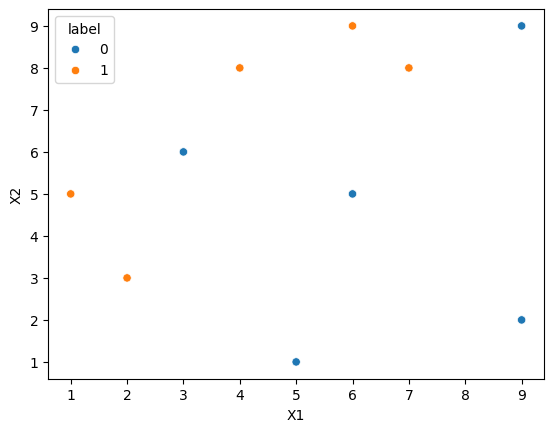

In [24]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [25]:
## step1: initialzie the weights for all row(alpha value)
df['weights']=1/df.shape[0] #initialize weihts for each row , 1/ no of rows

In [26]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [38]:
X=df.drop(columns=['label','weights']).values
y=df['label'].values

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt1=DecisionTreeClassifier(max_depth=1) #decision stump,ie dt with max_depth 1
dt1.fit(X,y) 

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

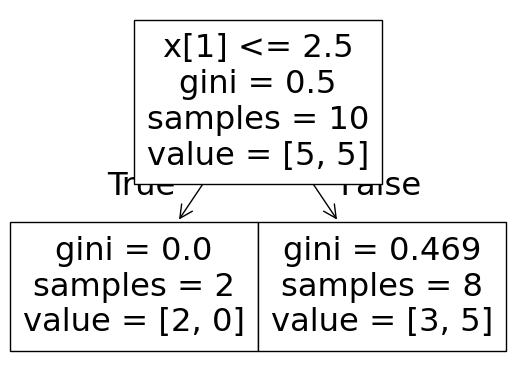

In [40]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

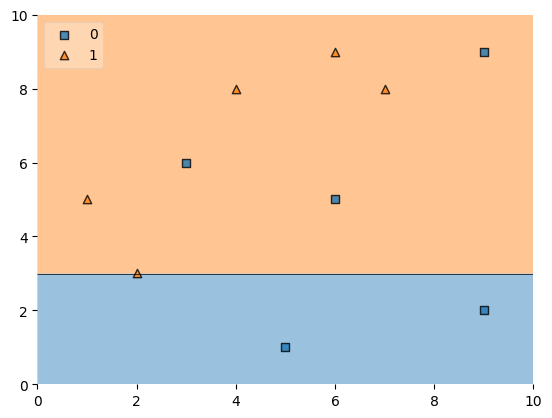

In [41]:
plot_decision_regions(X,y,clf=dt1,legend=2)

In [42]:
#step 3: predict the output
df['y_pred'] =dt1.predict(X)

In [45]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [ ]:
def calculate_model_weight(error): 
    return 1/2*np.log((1-error)/(error)) #0.5 ->1/2
    # This is the weight (α) assigned to a single weak learner (e.g., one decision stump) in the

In [49]:
#step4: claculate the model weight
alpha1= calculate_model_weight(0.3) # 0.1+0.1+0.1 =0.3
alpha1

np.float64(0.42364893019360184)

In [52]:
#step 4: inicreaes the weights for mis-classified points and decrease weights for correctly classified points

def update_row_weights(row,alpha=0.423):
    if row['label']==row['y_pred']:
        return row['weights']*np.exp(-alpha) ## drecrease for correctly classified
    else:
        return row['weights']*np.exp(alpha)


In [53]:
df['updated_weights']=df.apply(update_row_weights,axis=1)

In [54]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [55]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

In [56]:
#the sum of updated weights must be 1. so to do that we normalize the weights  by dividing all the weights by the sum
df['normalized_weights'] =df['updated_weights']/df['updated_weights'].sum()

In [57]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [ ]:
df['normalized_weights'].sum()

np.float64(1.0)

In [ ]:
# now wee need to create range
df['upper_range']=np.cumsum(df['normalized_weights'])

In [61]:
df['lower_range']=df['upper_range']-df['normalized_weights']

In [62]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,upper_range,lower_range
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,1,0.152653,0.166559,0.309508,0.142950
3,4,8,1,0.1,1,0.065508,0.071475,0.380983,0.309508
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,1,0.065508,0.071475,0.523933,0.452458
6,6,5,0,0.1,1,0.152653,0.166559,0.690492,0.523933
7,7,8,1,0.1,1,0.065508,0.071475,0.761967,0.690492
8,9,9,0,0.1,1,0.152653,0.166559,0.928525,0.761967
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [64]:
#create  a new dataset with the current dataset ,with equal number of rows as the currentdataset, and the new datase
#is created it by generating 10 random numbers and see where the random number lies in the range
#which ever range it lies, we pick that number

def create_new_dataset(df):
    indices = []

    for i in range(df.shape[0]):
        a = np.random.random()
        for index, row in df.iterrows():
            if row['upper_range'] > a and a > row['lower_range']:
                indices.append(index)
    return indices


In [66]:
index_values = create_new_dataset(df)
index_values

[2, 2, 6, 7, 8, 1, 8, 3, 4, 9]

In [68]:
second_df=df.iloc[index_values,[0,1,2,3]]

In [69]:
second_df

,X1,X2,label,weights
2,3,6,0,0.1
2,3,6,0,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
1,2,3,1,0.1
8,9,9,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
9,9,2,0,0.1


In [ ]:

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [80]:
dt2= DecisionTreeClassifier(max_depth=1)
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.346\nsamples = 9\nvalue = [7, 2]'),
 Text(0.625, 0.5, '  False')]

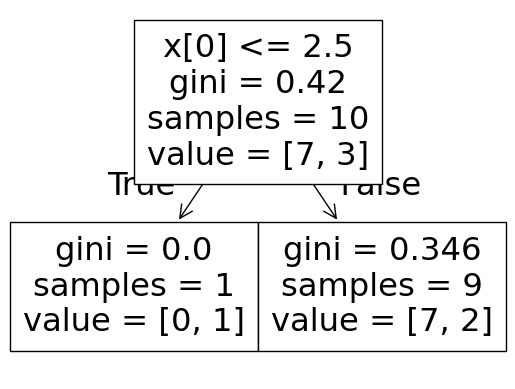

In [81]:
plot_tree(dt2)


<Axes: >

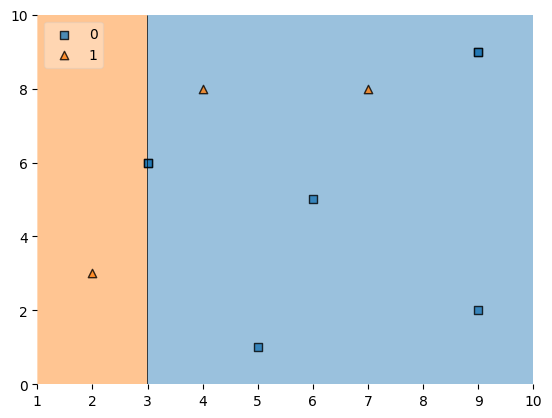

In [82]:

plot_decision_regions(X, y, clf=dt2, legend=2)


In [83]:
second_df['y_pred'] = dt2.predict(X)

In [84]:
second_df

,X1,X2,label,weights,y_pred
2,3,6,0,0.1,0
2,3,6,0,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
1,2,3,1,0.1,1
8,9,9,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
9,9,2,0,0.1,0


In [86]:

alpha2 = calculate_model_weight(0.1)
alpha2

np.float64(1.0986122886681098)

In [87]:

# Step 4 - Update weights
def update_row_weights(row,alpha=1.09):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [88]:


second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)

In [89]:


second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [91]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
2,3,6,0,0.1,0,0.033622,0.038922
2,3,6,0,0.1,0,0.033622,0.038922
6,6,5,0,0.1,0,0.033622,0.038922
7,7,8,1,0.1,0,0.297427,0.344313
8,9,9,0,0.1,0,0.033622,0.038922
1,2,3,1,0.1,1,0.033622,0.038922
8,9,9,0,0.1,0,0.033622,0.038922
3,4,8,1,0.1,0,0.297427,0.344313
4,5,1,0,0.1,0,0.033622,0.038922
9,9,2,0,0.1,0,0.033622,0.038922


In [95]:
second_df['upper_range'] = np.cumsum(second_df['nomalized_weights'])
second_df['lower_range'] = second_df['upper_range'] - second_df['nomalized_weights']


In [96]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights,upper_range,lower_range
2,3,6,0,0.1,0,0.033622,0.038922,0.038922,0.000000
2,3,6,0,0.1,0,0.033622,0.038922,0.077843,0.038922
6,6,5,0,0.1,0,0.033622,0.038922,0.116765,0.077843
7,7,8,1,0.1,0,0.297427,0.344313,0.461078,0.116765
8,9,9,0,0.1,0,0.033622,0.038922,0.500000,0.461078
1,2,3,1,0.1,1,0.033622,0.038922,0.538922,0.500000
8,9,9,0,0.1,0,0.033622,0.038922,0.577843,0.538922
3,4,8,1,0.1,0,0.297427,0.344313,0.922157,0.577843
4,5,1,0,0.1,0,0.033622,0.038922,0.961078,0.922157
9,9,2,0,0.1,0,0.033622,0.038922,1.000000,0.961078


In [97]:
second_df[['X1','X2','label','weights','y_pred','nomalized_weights','lower_range','upper_range']]
     

,X1,X2,label,weights,y_pred,nomalized_weights,lower_range,upper_range
2,3,6,0,0.1,0,0.038922,0.000000,0.038922
2,3,6,0,0.1,0,0.038922,0.038922,0.077843
6,6,5,0,0.1,0,0.038922,0.077843,0.116765
7,7,8,1,0.1,0,0.344313,0.116765,0.461078
8,9,9,0,0.1,0,0.038922,0.461078,0.500000
1,2,3,1,0.1,1,0.038922,0.500000,0.538922
8,9,9,0,0.1,0,0.038922,0.538922,0.577843
3,4,8,1,0.1,0,0.344313,0.577843,0.922157
4,5,1,0,0.1,0,0.038922,0.922157,0.961078
9,9,2,0,0.1,0,0.038922,0.961078,1.000000


In [98]:


index_values = create_new_dataset(second_df)

In [99]:

third_df = second_df.iloc[index_values,[0,1,2,3]]

In [100]:


third_df

,X1,X2,label,weights
7,7,8,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
3,4,8,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1


In [101]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [102]:

dt3 = DecisionTreeClassifier(max_depth=1)
dt3.fit(X,y)
     

DecisionTreeClassifier(max_depth=1)

<Axes: >

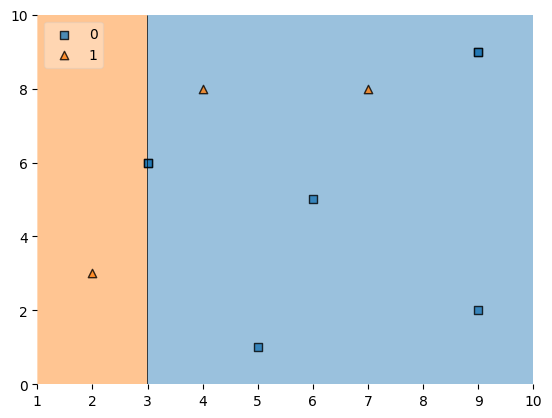

In [103]:


plot_decision_regions(X, y, clf=dt3, legend=2)

In [104]:
third_df['y_pred'] = dt3.predict(X)

In [105]:
third_df


,X1,X2,label,weights,y_pred
7,7,8,1,0.1,0
7,7,8,1,0.1,0
7,7,8,1,0.1,0
7,7,8,1,0.1,0
7,7,8,1,0.1,0
2,3,6,0,0.1,1
3,4,8,1,0.1,0
3,4,8,1,0.1,0
7,7,8,1,0.1,0
7,7,8,1,0.1,0


In [106]:


alpha3 = calculate_model_weight(0.7)
alpha3

np.float64(-0.4236489301936017)

In [107]:
print(alpha1,alpha2,alpha3)

0.42364893019360184 1.0986122886681098 -0.4236489301936017


In [108]:

query = np.array([1,5]).reshape(1,2)
dt1.predict(query)
     

array([1])

In [109]:

dt2.predict(query)

array([1])

In [110]:


dt3.predict(query)
     

array([1])

In [111]:

alpha1*1 + alpha2*(1) + alpha3*(1)


np.float64(1.09861228866811)

In [112]:


np.sign(1.09)

np.float64(1.0)

In [113]:

query = np.array([9,9]).reshape(1,2)
dt1.predict(query)

array([1])

In [114]:


dt2.predict(query)

array([0])

In [115]:


dt3.predict(query)


array([0])

In [116]:

alpha1*(1) + alpha2*(-1) + alpha3*(-1)

np.float64(-0.2513144282809062)

In [117]:


np.sign(-0.25)
     

np.float64(-1.0)